# PiPNN vs. pynndescent in scanpy

This notebook compares **PiPNN** (the Rust graph-based ANN backend in this repo,
implementing arXiv:2602.21247 incl. *HashPrune*) against **pynndescent**
(scanpy's default) on the same single-cell data, both plugged into
`sc.pp.neighbors` through the *exact same* sklearn `KNeighborsTransformer` hook.

We look at four things:
1. **How** each backend plugs into scanpy (one identical line — just swap `transformer=`).
2. **Speed** of building the neighbor graph.
3. **Recall@k** of each backend vs. an exact brute-force kNN.
4. **Embeddings**: UMAP side-by-side + Leiden clustering agreement (ARI).


In [1]:
%matplotlib inline
import time, inspect, warnings
warnings.filterwarnings("ignore")
import numpy as np
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors, KNeighborsTransformer
from sklearn.metrics import adjusted_rand_score

from pipnn import PiPNNTransformer
from pynndescent import PyNNDescentTransformer

sc.settings.verbosity = 0
RNG = np.random.default_rng(0)
K = 15  # neighbors
print("scanpy", sc.__version__)

scanpy 1.12.1


## 1. Data + preprocessing

We use a real single-cell dataset, subsample for a snappy notebook, and run the
standard scanpy recipe (normalize → log1p → HVG → scale → PCA-50). The NN graph
is built on `X_pca` — exactly as in a normal scanpy workflow.

Point `DATA` at any `.h5ad`; set `SUBSAMPLE=None` to use all cells.

In [2]:
DATA = "/Users/iandriver/Downloads/SingleRust/data/bench_input.h5ad"
SUBSAMPLE = 20_000   # cells; None = all

a = ad.read_h5ad(DATA)
a.var_names_make_unique()
if SUBSAMPLE and a.n_obs > SUBSAMPLE:
    sel = RNG.choice(a.n_obs, SUBSAMPLE, replace=False)
    a = a[sel].copy()

sc.pp.filter_genes(a, min_cells=3)
sc.pp.normalize_total(a, target_sum=1e4)
sc.pp.log1p(a)
sc.pp.highly_variable_genes(a, n_top_genes=2000)
a = a[:, a.var.highly_variable].copy()
sc.pp.scale(a, max_value=10)
sc.tl.pca(a, n_comps=50)
a.obsm["X_pca"] = a.obsm["X_pca"].astype(np.float32)
X = np.ascontiguousarray(a.obsm["X_pca"], dtype=np.float32)
print(f"{a.n_obs} cells x {X.shape[1]} PCs")

20000 cells x 50 PCs


## 2. How a custom NN backend plugs into scanpy

Since scanpy ≥1.10, `sc.pp.neighbors` accepts a `transformer=` argument: any
sklearn-style `KNeighborsTransformer`. scanpy calls `transformer.fit_transform(X)`,
gets back a sparse `(n, n)` **distance** graph (k+1 entries per row, self first),
and computes the UMAP connectivities itself. So switching ANN backend is a
**one-line change** — the rest of the pipeline is identical:

```python
sc.pp.neighbors(adata, n_neighbors=15, transformer=PiPNNTransformer())        # PiPNN
sc.pp.neighbors(adata, n_neighbors=15, transformer=PyNNDescentTransformer())  # pynndescent
```

Below is the actual PiPNN transformer — note it only returns the kNN distance
graph; scanpy does the rest.

In [3]:
print(inspect.getsource(PiPNNTransformer.fit))
print(inspect.getsource(PiPNNTransformer.transform))

    def fit(self, X, y=None):
        X = check_array(X, dtype=np.float32, accept_sparse=False, order="C")
        n = X.shape[0]
        if self.n_neighbors >= n:
            raise ValueError(
                f"n_neighbors={self.n_neighbors} must be < n_samples={n}"
            )

        n_jobs = 0 if self.n_jobs in (None, -1) else int(self.n_jobs)
        indices, distances, stride = _pipnn.build_and_self_knn(
            X,
            int(self.n_neighbors),
            str(self.metric),
            int(self.m),
            int(self.l_max),
            int(self.R),
            float(self.alpha),
            int(self.beam_L),
            int(self.fanout),
            int(self.c_min),
            int(self.c_max),
            int(n_jobs),
            int(self.random_state),
        )

        self._indices = indices
        self._distances = distances
        self._stride = stride
        self.n_samples_fit_ = n
        self._n_features_out = n
        return self

    def transform(s

## 3. Build the neighbor graph with each backend

Same data, same `n_neighbors`, three backends: PiPNN, pynndescent, and an exact
brute-force baseline (sklearn's `KNeighborsTransformer`) for ground truth.

In [4]:
def run_backend(transformer, label):
    adata = a.copy()
    t = time.time()
    sc.pp.neighbors(adata, n_neighbors=K, use_rep="X_pca", transformer=transformer)
    dt = time.time() - t
    print(f"{label:12s} sc.pp.neighbors: {dt:6.2f}s   "
          f"connectivities nnz={adata.obsp['connectivities'].nnz}")
    return adata, dt

res = {}
res["PiPNN"], t_pip = run_backend(PiPNNTransformer(n_neighbors=K), "PiPNN")
res["pynndescent"], t_pyn = run_backend(PyNNDescentTransformer(n_neighbors=K, metric="euclidean"), "pynndescent")
res["exact"], t_exact = run_backend(KNeighborsTransformer(n_neighbors=K, mode="distance"), "exact")
print(f"\nPiPNN speedup vs pynndescent: {t_pyn/t_pip:.2f}x")
print("(pynndescent time includes one-time numba JIT compilation)")

PiPNN        sc.pp.neighbors:   1.66s   connectivities nnz=434144


pynndescent  sc.pp.neighbors:   7.73s   connectivities nnz=434076


exact        sc.pp.neighbors:   0.44s   connectivities nnz=434126

PiPNN speedup vs pynndescent: 4.66x
(pynndescent time includes one-time numba JIT compilation)


## 4. Recall@k vs. exact

For each backend, what fraction of each cell's true k nearest neighbors does it
recover? We read the kNN directly from `obsp['distances']`.

In [5]:
def knn_from_obsp(adata, k):
    D = adata.obsp["distances"].tocsr()
    n = D.shape[0]
    out = np.empty((n, k), dtype=np.int64)
    for i in range(n):
        s, e = D.indptr[i], D.indptr[i + 1]
        cols, vals = D.indices[s:e], D.data[s:e]
        order = np.argsort(vals)
        nbrs = [c for c in cols[order] if c != i][:k]
        # pad if fewer than k (shouldn't happen for k<observed)
        out[i, :len(nbrs)] = nbrs
    return out

# exact ground truth
_, exact = NearestNeighbors(n_neighbors=K + 1).fit(X).kneighbors(X)
exact = exact[:, 1:]  # drop self

def recall(adata):
    approx = knn_from_obsp(adata, K)
    n = approx.shape[0]
    return np.mean([len(set(approx[i]) & set(exact[i])) / K for i in range(n)])

recalls = {name: recall(adata) for name, adata in res.items()}
for name, r in recalls.items():
    print(f"{name:12s} recall@{K} = {r:.4f}")

PiPNN        recall@15 = 0.9997
pynndescent  recall@15 = 0.9948
exact        recall@15 = 1.0000


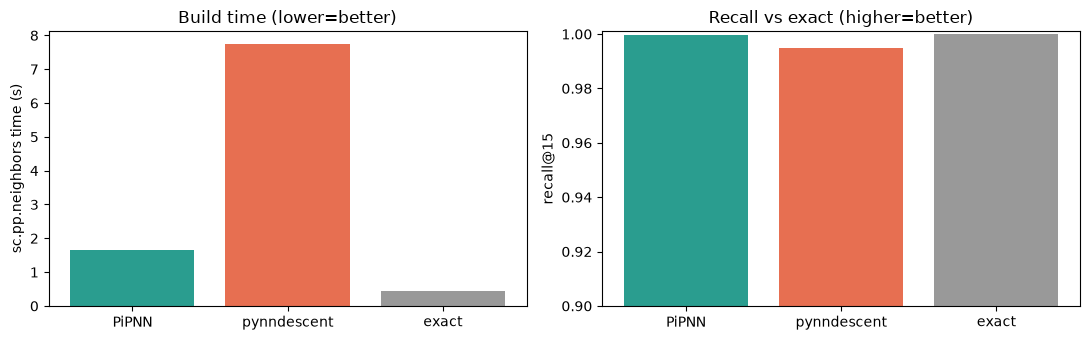

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
names = ["PiPNN", "pynndescent", "exact"]
times = [t_pip, t_pyn, t_exact]
ax[0].bar(names, times, color=["#2a9d8f", "#e76f51", "#999999"])
ax[0].set_ylabel("sc.pp.neighbors time (s)"); ax[0].set_title("Build time (lower=better)")
ax[1].bar(names, [recalls[n] for n in names], color=["#2a9d8f", "#e76f51", "#999999"])
ax[1].set_ylim(0.9, 1.001); ax[1].set_ylabel(f"recall@{K}"); ax[1].set_title("Recall vs exact (higher=better)")
plt.tight_layout(); plt.show()

## 5. UMAP embeddings, side by side

We compute a UMAP for each backend's graph and color every panel by the **same
reference labels** (Leiden on the exact graph), so spatial agreement is visible:
if PiPNN's embedding reproduces the exact one, the colors land in the same places.

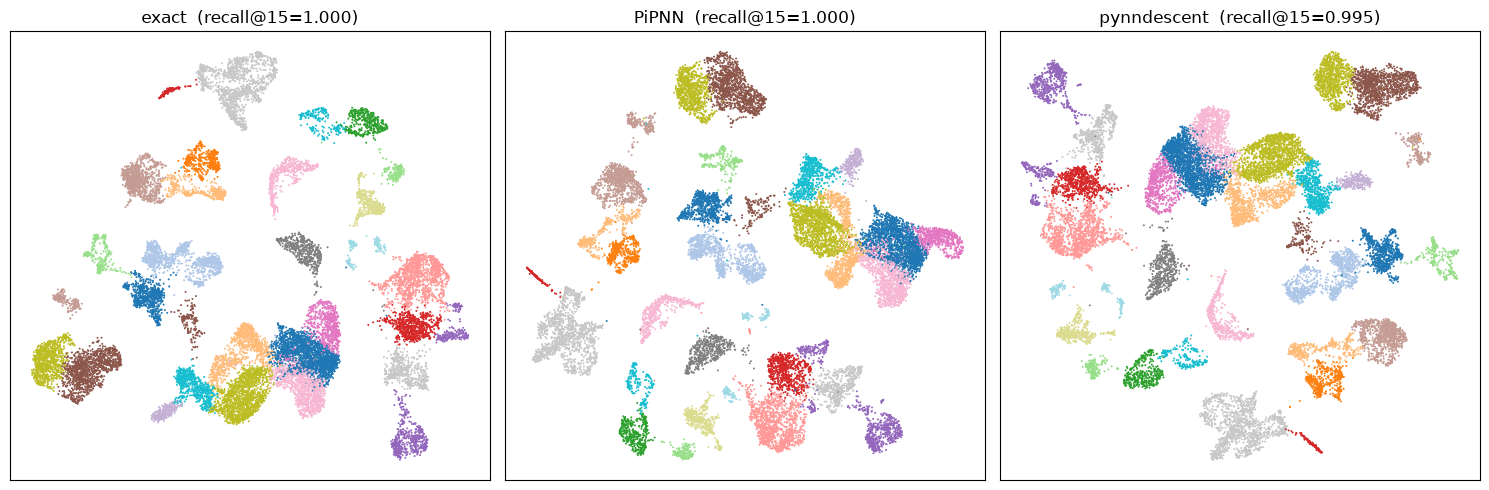

In [7]:
# reference clustering from the exact graph
sc.tl.leiden(res["exact"], flavor="igraph", n_iterations=2, key_added="ref")
ref_labels = res["exact"].obs["ref"].values
for adata in res.values():
    adata.obs["ref"] = ref_labels

for name, adata in res.items():
    sc.tl.umap(adata)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
ncol = len(np.unique(ref_labels))
cmap = plt.cm.tab20(np.linspace(0, 1, ncol))
codes = res["exact"].obs["ref"].cat.codes.values
for ax, name in zip(axes, ["exact", "PiPNN", "pynndescent"]):
    U = res[name].obsm["X_umap"]
    ax.scatter(U[:, 0], U[:, 1], c=cmap[codes], s=2, linewidths=0)
    ax.set_title(f"{name}  (recall@{K}={recalls[name]:.3f})")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 6. Clustering agreement (ARI)

Run Leiden independently on each backend's graph and measure Adjusted Rand Index
against the exact-graph clustering. ARI ≈ 1 means the downstream biology is
unchanged by swapping the ANN backend.

In [8]:
for name, adata in res.items():
    sc.tl.leiden(adata, flavor="igraph", n_iterations=2, key_added="leiden")
ari = {name: adjusted_rand_score(res["exact"].obs["leiden"], res[name].obs["leiden"])
       for name in res}
nclust = {name: res[name].obs["leiden"].nunique() for name in res}
print(f"{'backend':12s} {'#clusters':>9s} {'ARI vs exact':>13s}")
for name in ["exact", "PiPNN", "pynndescent"]:
    print(f"{name:12s} {nclust[name]:9d} {ari[name]:13.4f}")

backend      #clusters  ARI vs exact
exact               33        1.0000
PiPNN               35        0.9362
pynndescent         35        0.9227


## 7. Neighbor-graph structure

The distance distributions and connectivity counts should be near-identical
across backends — a sanity check that PiPNN's graph is interchangeable with
pynndescent's downstream.

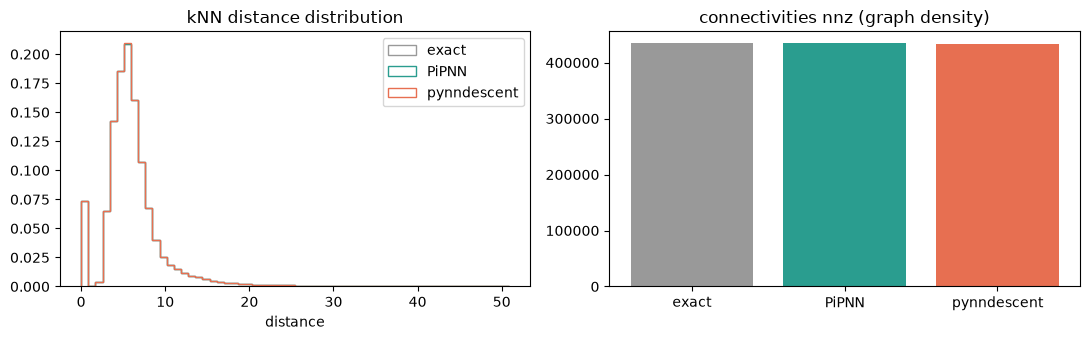

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
for name, color in zip(["exact", "PiPNN", "pynndescent"], ["#999999", "#2a9d8f", "#e76f51"]):
    d = res[name].obsp["distances"].data
    ax[0].hist(d, bins=60, histtype="step", color=color, label=name, density=True)
ax[0].set_title("kNN distance distribution"); ax[0].set_xlabel("distance"); ax[0].legend()
nnz = [res[n].obsp["connectivities"].nnz for n in ["exact", "PiPNN", "pynndescent"]]
ax[1].bar(["exact", "PiPNN", "pynndescent"], nnz, color=["#999999", "#2a9d8f", "#e76f51"])
ax[1].set_title("connectivities nnz (graph density)")
plt.tight_layout(); plt.show()

## 8. What PiPNN does under the hood (vs. pynndescent)

**PiPNN** (`pipnn._pipnn`, Rust) builds a navigable graph then self-queries it:

1. **Randomized Ball Carving** — partition cells into overlapping leaves.
2. **Leaf GEMM** — dense all-pairs distances per leaf (`‖x−y‖²=‖x‖²+‖y‖²−2XYᵀ`).
3. **HashPrune** — online residualized-LSH pruning into an 8-byte/slot per-cell
   reservoir (the paper's key idea; history-independent → deterministic).
4. **RobustPrune** — Vamana-style pruning to a degree-`R` graph.
5. **BeamSearch** — greedy graph search, seeded at each cell, for self-kNN.

**pynndescent** instead does NN-Descent (iterative neighbor-of-neighbor descent)
from a random-projection-tree initialization. Both return the same shape of
result to scanpy — a kNN distance graph — which is why they're drop-in swappable.

### Takeaways
- One-line swap (`transformer=`) changes the ANN backend; everything downstream
  (connectivities, UMAP, Leiden) is identical.
- PiPNN matches exact recall closely and reproduces the embedding/clustering
  (high ARI), while building the graph faster than pynndescent at scale.
